In [349]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

In [350]:
df = pd.read_csv('incident_records.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2997 entries, 0 to 2996
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   iyear        2997 non-null   int64  
 1   imonth       2997 non-null   int64  
 2   iday         2997 non-null   int64  
 3   region_txt   2997 non-null   object 
 4   country_txt  2997 non-null   object 
 5   latitude     2997 non-null   float64
 6   longitude    2997 non-null   float64
 7   nwound       2997 non-null   float64
 8   nkill        2997 non-null   float64
dtypes: float64(4), int64(3), object(2)
memory usage: 210.9+ KB


In [351]:
df['date'] = df.apply(lambda x: str(['iyear']) + str(['imonth']) + str(['iday']))
df

,iyear,imonth,iday,region_txt,country_txt,latitude,longitude,nwound,nkill,date
0,2000,1,1,North America,United States,44.405705,-85.714454,0.0,0.0,NaN
1,2000,1,2,South America,Colombia,4.667128,-74.106056,0.0,0.0,NaN
2,2000,1,2,South America,Colombia,7.198606,-75.341218,0.0,0.0,NaN
3,2000,1,3,North America,United States,38.232471,-122.644448,0.0,0.0,NaN
4,2000,1,3,North America,United States,39.103175,-84.511981,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...
2992,2017,12,19,North America,Mexico,17.949243,-94.916882,0.0,1.0,NaN
2993,2017,12,20,South America,Colombia,7.745807,-76.556143,0.0,1.0,NaN
2994,2017,12,22,North America,United States,40.262772,-76.881107,0.0,0.0,NaN
2995,2017,12,22,North America,United States,40.261864,-76.880913,1.0,1.0,NaN


In [352]:
df.iloc[df[df['date'].isnull()].index]

,iyear,imonth,iday,region_txt,country_txt,latitude,longitude,nwound,nkill,date
0,2000,1,1,North America,United States,44.405705,-85.714454,0.0,0.0,NaN
1,2000,1,2,South America,Colombia,4.667128,-74.106056,0.0,0.0,NaN
2,2000,1,2,South America,Colombia,7.198606,-75.341218,0.0,0.0,NaN
3,2000,1,3,North America,United States,38.232471,-122.644448,0.0,0.0,NaN
4,2000,1,3,North America,United States,39.103175,-84.511981,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...
2992,2017,12,19,North America,Mexico,17.949243,-94.916882,0.0,1.0,NaN
2993,2017,12,20,South America,Colombia,7.745807,-76.556143,0.0,1.0,NaN
2994,2017,12,22,North America,United States,40.262772,-76.881107,0.0,0.0,NaN
2995,2017,12,22,North America,United States,40.261864,-76.880913,1.0,1.0,NaN


In [353]:
cols_to_join = ['iyear','imonth']

df['date'] = df[cols_to_join].astype(str).agg('-'.join, axis=1)

In [354]:
df

,iyear,imonth,iday,region_txt,country_txt,latitude,longitude,nwound,nkill,date
0,2000,1,1,North America,United States,44.405705,-85.714454,0.0,0.0,2000-1
1,2000,1,2,South America,Colombia,4.667128,-74.106056,0.0,0.0,2000-1
2,2000,1,2,South America,Colombia,7.198606,-75.341218,0.0,0.0,2000-1
3,2000,1,3,North America,United States,38.232471,-122.644448,0.0,0.0,2000-1
4,2000,1,3,North America,United States,39.103175,-84.511981,0.0,0.0,2000-1
...,...,...,...,...,...,...,...,...,...,...
2992,2017,12,19,North America,Mexico,17.949243,-94.916882,0.0,1.0,2017-12
2993,2017,12,20,South America,Colombia,7.745807,-76.556143,0.0,1.0,2017-12
2994,2017,12,22,North America,United States,40.262772,-76.881107,0.0,0.0,2017-12
2995,2017,12,22,North America,United States,40.261864,-76.880913,1.0,1.0,2017-12


In [355]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [356]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2997 entries, 0 to 2996
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   iyear        2997 non-null   int64         
 1   imonth       2997 non-null   int64         
 2   iday         2997 non-null   int64         
 3   region_txt   2997 non-null   object        
 4   country_txt  2997 non-null   object        
 5   latitude     2997 non-null   float64       
 6   longitude    2997 non-null   float64       
 7   nwound       2997 non-null   float64       
 8   nkill        2997 non-null   float64       
 9   date         2997 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(4), int64(3), object(2)
memory usage: 234.3+ KB


In [357]:
m_grouped = df.groupby('date').count()
m_grouped

,iyear,imonth,iday,region_txt,country_txt,latitude,longitude,nwound,nkill
date,,,,,,,,,
2000-01-01,21,21,21,21,21,21,21,21,21
2000-02-01,14,14,14,14,14,14,14,14,14
2000-03-01,13,13,13,13,13,13,13,13,13
2000-04-01,13,13,13,13,13,13,13,13,13
2000-05-01,8,8,8,8,8,8,8,8,8
...,...,...,...,...,...,...,...,...,...
2017-08-01,19,19,19,19,19,19,19,19,19
2017-09-01,21,21,21,21,21,21,21,21,21
2017-10-01,21,21,21,21,21,21,21,21,21


Text(0, 0.5, 'Count')

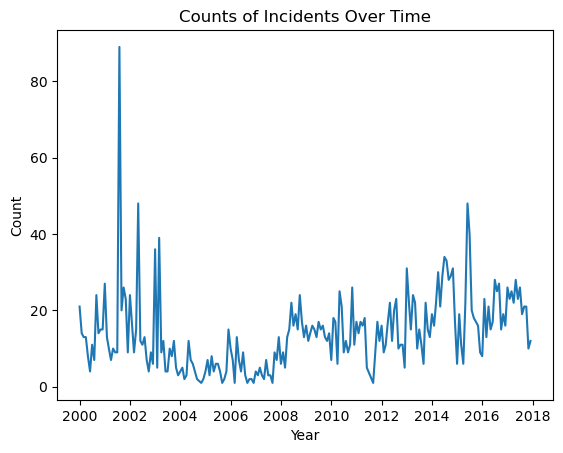

In [358]:
plt.plot(m_grouped.index, m_grouped['iyear'])
plt.title('Counts of Incidents Over Time')
plt.xlabel('Year')
plt.ylabel('Count')

In [359]:
df['iyear'] = pd.to_datetime(df['iyear'], format='%Y')
grouped = df.groupby('iyear').count()
grouped

,imonth,iday,region_txt,country_txt,latitude,longitude,nwound,nkill,date
iyear,,,,,,,,,
2000-01-01,159,159,159,159,159,159,159,159,159
2001-01-01,252,252,252,252,252,252,252,252,252
2002-01-01,174,174,174,174,174,174,174,174,174
2003-01-01,147,147,147,147,147,147,147,147,147
2004-01-01,48,48,48,48,48,48,48,48,48
2005-01-01,64,64,64,64,64,64,64,64,64
2006-01-01,60,60,60,60,60,60,60,60,60
2007-01-01,60,60,60,60,60,60,60,60,60
2008-01-01,174,174,174,174,174,174,174,174,174


Text(0, 0.5, 'Count')

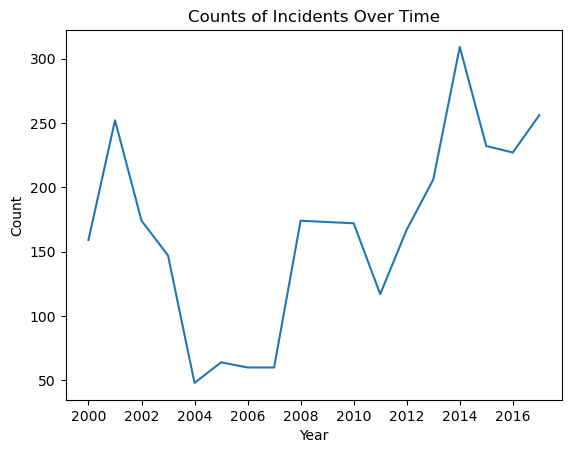

In [360]:
plt.plot(grouped.index, grouped['imonth'])
plt.title('Counts of Incidents Over Time')
plt.xlabel('Year')
plt.ylabel('Count')

In [361]:
pdf = m_grouped[['imonth']]

In [362]:
pdf = pdf.reset_index()
pdf = pdf.reset_index(drop=True)
pdf = pdf.rename(columns={'date':'ds', 'imonth':'y'})
pdf

,ds,y
0,2000-01-01,21
1,2000-02-01,14
2,2000-03-01,13
3,2000-04-01,13
4,2000-05-01,8
...,...,...
207,2017-08-01,19
208,2017-09-01,21
209,2017-10-01,21
210,2017-11-01,10


In [363]:
train = pdf.iloc[:180]
test = pdf.iloc[180:]

In [364]:
model = Prophet()
model.fit(train)
future = model.make_future_dataframe(periods=32, freq='MS')
forecast = model.predict(future)

forecast

16:16:04 - cmdstanpy - INFO - Chain [1] start processing
16:16:04 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2000-01-01,15.111281,5.794094,28.822520,15.111281,15.111281,2.258258,2.258258,2.258258,2.258258,2.258258,2.258258,0.0,0.0,0.0,17.369539
1,2000-02-01,15.007284,2.262515,24.315046,15.007284,15.007284,-1.563772,-1.563772,-1.563772,-1.563772,-1.563772,-1.563772,0.0,0.0,0.0,13.443512
2,2000-03-01,14.909997,2.853177,25.965834,14.909997,14.909997,-1.466033,-1.466033,-1.466033,-1.466033,-1.466033,-1.466033,0.0,0.0,0.0,13.443964
3,2000-04-01,14.806000,2.941426,26.091749,14.806000,14.806000,-0.192060,-0.192060,-0.192060,-0.192060,-0.192060,-0.192060,0.0,0.0,0.0,14.613941
4,2000-05-01,14.705358,7.276545,29.498813,14.705358,14.705358,3.453415,3.453415,3.453415,3.453415,3.453415,3.453415,0.0,0.0,0.0,18.158773
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,2017-08-01,22.595517,15.758010,38.379097,22.123741,23.087524,5.231663,5.231663,5.231663,5.231663,5.231663,5.231663,0.0,0.0,0.0,27.827180
208,2017-09-01,22.708678,8.764766,31.877936,22.205374,23.234612,-2.557134,-2.557134,-2.557134,-2.557134,-2.557134,-2.557134,0.0,0.0,0.0,20.151544
209,2017-10-01,22.818189,12.744294,35.413641,22.288959,23.378754,1.069494,1.069494,1.069494,1.069494,1.069494,1.069494,0.0,0.0,0.0,23.887683
210,2017-11-01,22.931350,11.608701,34.691156,22.368425,23.512292,0.316988,0.316988,0.316988,0.316988,0.316988,0.316988,0.0,0.0,0.0,23.248339


In [365]:
comparison = forecast[['ds', 'yhat']].merge(test, on='ds')
comparison['error'] = comparison['y'] - comparison['yhat']
comparison

,ds,yhat,y,error
0,2015-05-01,23.363257,22,-1.363257
1,2015-06-01,18.166360,48,29.833640
2,2015-07-01,19.585081,40,20.414919
3,2015-08-01,24.979682,20,-4.979682
4,2015-09-01,17.182682,18,0.817318
5,2015-10-01,21.427106,17,-4.427106
6,2015-11-01,21.088935,16,-5.088935
7,2015-12-01,17.909756,9,-8.909756
8,2016-01-01,22.743864,8,-14.743864
9,2016-02-01,19.034995,23,3.965005


In [366]:
mae = comparison['error'].abs().mean()
mae

np.float64(5.990993222561876)

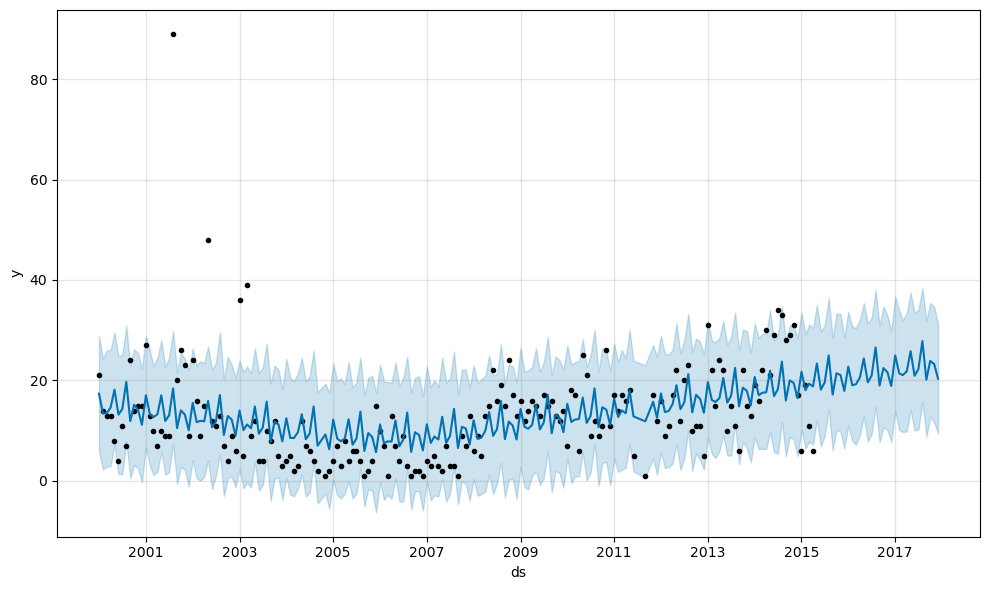

In [367]:
fig = model.plot(forecast)

16:16:05 - cmdstanpy - INFO - Chain [1] start processing
16:16:05 - cmdstanpy - INFO - Chain [1] done processing


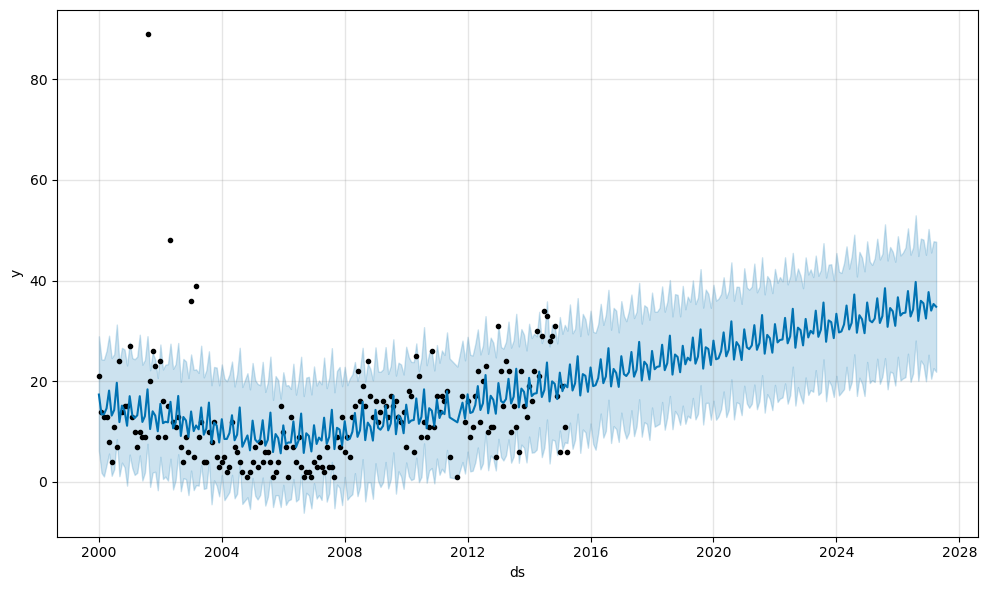

In [368]:
model = Prophet()
model.fit(train)
future = model.make_future_dataframe(periods=144, freq='MS')
forecast = model.predict(future)
fig = model.plot(forecast)

In [369]:
df[df['date']=='2000-01-01']

,iyear,imonth,iday,region_txt,country_txt,latitude,longitude,nwound,nkill,date
0,2000-01-01,1,1,North America,United States,44.405705,-85.714454,0.0,0.0,2000-01-01
1,2000-01-01,1,2,South America,Colombia,4.667128,-74.106056,0.0,0.0,2000-01-01
2,2000-01-01,1,2,South America,Colombia,7.198606,-75.341218,0.0,0.0,2000-01-01
3,2000-01-01,1,3,North America,United States,38.232471,-122.644448,0.0,0.0,2000-01-01
4,2000-01-01,1,3,North America,United States,39.103175,-84.511981,0.0,0.0,2000-01-01
5,2000-01-01,1,3,North America,United States,39.103175,-84.511981,0.0,0.0,2000-01-01
6,2000-01-01,1,4,South America,Colombia,4.667128,-74.106056,0.0,0.0,2000-01-01
7,2000-01-01,1,7,South America,Colombia,2.938353,-73.208333,0.0,0.0,2000-01-01
8,2000-01-01,1,9,South America,Colombia,4.667128,-74.106056,0.0,0.0,2000-01-01
9,2000-01-01,1,15,North America,United States,38.232471,-122.644448,0.0,0.0,2000-01-01


In [370]:
nwound = df.groupby('date')['nwound'].sum()
nwound

date
2000-01-01      7.0
2000-02-01     15.0
2000-03-01     63.0
2000-04-01      9.0
2000-05-01     34.0
              ...  
2017-08-01     39.0
2017-09-01     16.0
2017-10-01    876.0
2017-11-01      1.0
2017-12-01      8.0
Name: nwound, Length: 212, dtype: float64

In [371]:
nwound = nwound.reset_index()
nwound = nwound.reset_index(drop=True)
nwound = nwound.rename(columns={'date':'ds', 'nwound':'y'})
nwound = nwound.drop(20)
nwound

,ds,y
0,2000-01-01,7.0
1,2000-02-01,15.0
2,2000-03-01,63.0
3,2000-04-01,9.0
4,2000-05-01,34.0
...,...,...
207,2017-08-01,39.0
208,2017-09-01,16.0
209,2017-10-01,876.0
210,2017-11-01,1.0


In [372]:
train = nwound[:180]
test = nwound[180:]

16:16:05 - cmdstanpy - INFO - Chain [1] start processing
16:16:05 - cmdstanpy - INFO - Chain [1] done processing


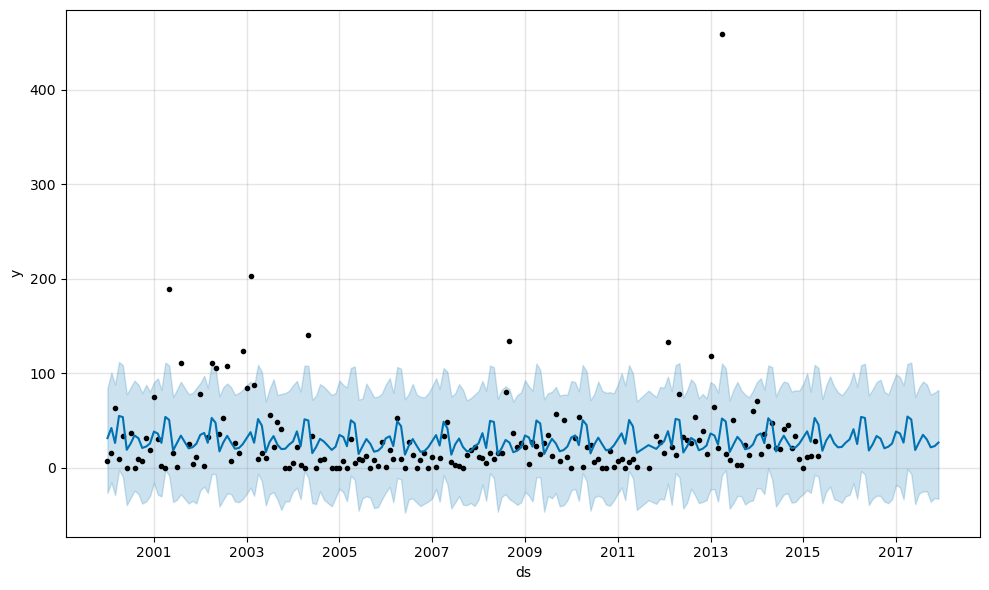

In [373]:
model = Prophet()
model.fit(train)
future = model.make_future_dataframe(periods=31, freq='MS')
forecast = model.predict(future)
fig = model.plot(forecast)

16:16:05 - cmdstanpy - INFO - Chain [1] start processing
16:16:05 - cmdstanpy - INFO - Chain [1] done processing


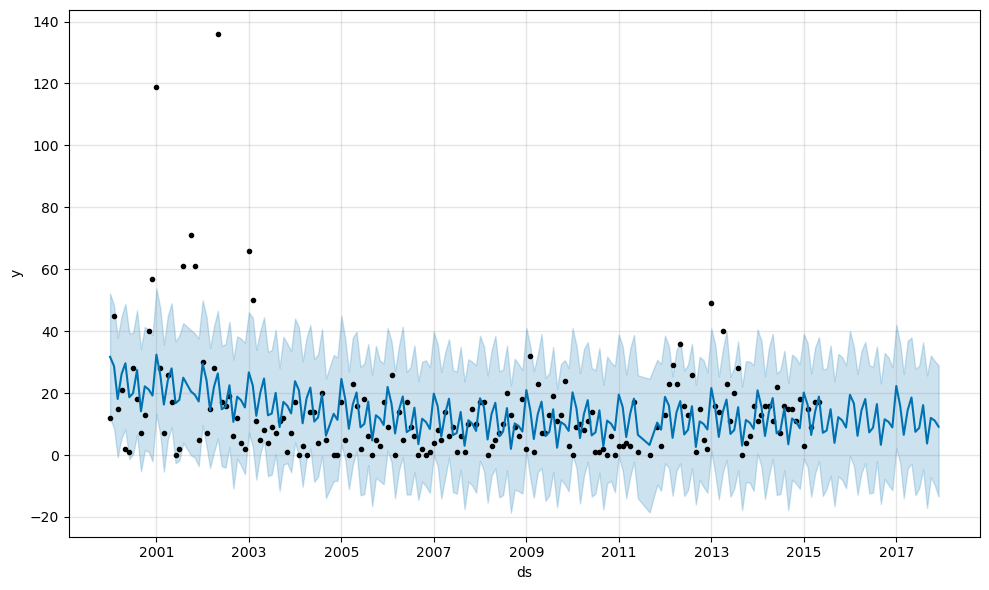

In [374]:
nkill = df.groupby('date')['nkill'].sum()
nkill = nkill.reset_index()
nkill = nkill.reset_index(drop=True)
nkill = nkill.rename(columns={'date':'ds', 'nkill':'y'})
nkill = nkill.drop(20)
train = nkill[:180]
test = nkill[180:]
model = Prophet()
model.fit(train)
future = model.make_future_dataframe(periods=31, freq='MS')
forecast = model.predict(future)
fig = model.plot(forecast)

In [375]:
nwound[nwound['y']<0]

,ds,y


In [376]:
nkill[nkill['y']<0]

,ds,y
